***
# Notes
***

1. fitting basic neural net

In [1]:
import dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

seed = 123

df = dataset.read_agg(month_start=1, month_end=12)
df = df[df['pickup_year'] == 2024]

2026-04-02 11:09:02.383530: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-02 11:09:02.702898: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-02 11:09:04.470430: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/kv/education/ml/groupwork/models/ride_demand/dataset.py:276: FutureWarning: Downcasti

# Preprocess

In [ ]:
realfrom sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Recast object types -> category
# Not sure why this changes from typecasting in `dataset.clean()`
df = df.astype({
    'vendor': 'category',
    # 'ratecode': 'category',
    'pickup_zone': 'category',
    'dropoff_zone': 'category',
    'route': 'category',
    'fog': 'bool',  
    'low_vis': 'bool',  
    'thunder': 'bool',  
    'hail': 'bool',  
    'freezing_rain': 'bool',  
    'haze': 'bool',
    'holiday': 'category',
})

# Remove waste columns
df = df.drop(errors='ignore', columns=[
    # 'pickup_zone',
    # 'dropoff_zone',
    'pickup_date',
    'service_route',
    'pickup_service_zone',
    'dropoff_service_zone',
    'pickup_week',
    'pickup_day',
    'total_passenger_count',  
    'avg_passenger_count',    
    'total_trip_distance',    
    'avg_trip_distance',      
    'total_fare_amount',      
    'avg_fare_amount',        
    'total_extra',            
    'avg_extra',              
    'total_mta_tax',          
    'avg_mta_tax',            
    'total_tip_amount',       
    'avg_tip_amount',         
    'total_tolls_amount',     
    'avg_tolls_amount',       
    'total_impr_surcharge',
    'avg_impr_surcharge',     
    'total_revenue',          
    'avg_revenue',            
    'total_airport_fee',      
    'avg_airport_fee',       
])

In [3]:
# Onehot encode the following:
#
#  4   pickup_service_zone    category
#  5   pickup_zone            category  
#  6   dropoff_service_zone   category
#  7   dropoff_zone           category  
#  8   route                  category  
#  9   service_route          category  
#  10  vendor                 category  
#  11  ratecode               category  [NOT USED]
#  12  payment_type           category  [NOT USED]
#
# These columns only have a few categories
#
# => onehot encoding is okay
columns_to_onehot_encode = [
    # 'pickup_service_zone',
    # 'dropoff_service_zone',
    # 'service_route',
    'vendor',
    'pickup_dow',
    # 'ratecode',
    # 'payment_type',
]

# These columns have LOADS of categories
#
# => ordinal encoding is needed             <---- not doing this gives 500GB encoded dataset
#``
# (tried TargetEncoder, but still ended up at 22GB - sticking to ordinal)
columns_to_ordinal_encode = [
    'pickup_zone',
    'dropoff_zone',
    'route',
    'holiday'
]

# Split `y` BEFORE pipeline
y = df['total_ride_count']
X = df.drop(columns=['total_ride_count'])

# Pipeline
#
# Transfroms the categorical columns to onehot-encoded types
pipeline = ColumnTransformer(
    transformers=[
        #                               +--- `sparse_output=True` stops the encoder duplicating data
        #                               |
        ("onehot", OneHotEncoder(sparse_output=True), columns_to_onehot_encode), 
        ("ordinal", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), columns_to_ordinal_encode),
    ],
    remainder='passthrough'
)
# pipeline.set_output(transform='pandas') # DEPRECATED: returning pandas cost too much memory
X_encoded = pipeline.fit_transform(X)

# Train vs Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=seed)

# Train vs Validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=seed)

# Cast datatypes of booleans to floats
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

# Scale for neural net

In [14]:
# Neural nets require the datasets to be scaled, otherwise it'll get drawn to larger numbers
# in the dataset
#
# y values were logged, as the dominance of larger values was skewing the dataset, even after scaling

from sklearn.preprocessing import StandardScaler

scaler_y = StandardScaler()
scaler_X = StandardScaler()

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

y_train_scaled = scaler_y.fit_transform(y_train_log.values.reshape(-1, 1))
X_train_scaled = scaler_X.fit_transform(X_train)

y_val_scaled = scaler_y.transform(y_val_log.values.reshape(-1, 1))
X_val_scaled = scaler_X.transform(X_val)

y_test_scaled = scaler_y.transform(y_test_log.values.reshape(-1, 1))
X_test_scaled = scaler_X.transform(X_test)

print("Range of y values should be between -3 & 3")
print(f"range: {y_train_scaled.min()} - {y_train_scaled.max()}")

print("\ny std deviation should be ~1")
print(f"std: {y_train_scaled.std()}")

Range of y values should be between -3 & 3
range: -0.9938212967445378 - 4.619098050508858

y std deviation should be ~1
std: 0.9999999999999998


# Train

In [ ]:
from tensorflow.keras import layers, optimizers

# NOTE! All y values are logged for training purposes, so MAE & MSE scores aren't explicitly comparable to true y values

# Fine-tuning workflow
#
# 1. added 2 more hidden layers - rule of thumb is that depth helps with more 
#    compelx data, but can increase overfitting
# 2. needs at least 30 epochs
# 3. batch normalization ...
# 4. lowered learning rate to 0.00075 (default=0.001)
# 5. changed from MSE -> MAE loss function, but MSE seems to reduce much faster - will try going back
#        --- 5. update: MSE is bad idea - lower end values are the main issues of the dataset
# 6. more layers working, gonna try a smaller layer in the middle
#        --- trying removing the smaller layer for a larger 1
nn = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(27,)),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.1),

    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),

    layers.Dense(1), # <--- no activation here == output a singular, raw number 
])

nn.compile(
    optimizer=optimizers.Adam(learning_rate=0.00075),
    loss='mae', # MAE > MSE since smaller y values are causing the issues
                # MSE comes down faster than MAE anyway
    metrics=['mae', 'mse']
)

nn.summary()

nn.fit(X_train_scaled, y_train_scaled, epochs=10, batch_size=256, validation_data=(X_val_scaled, y_val_scaled))

Model: "sequential_7"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_49 (Dense)                │ (None, 256)            │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 192)            │        49,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼───────────────────

/nix/store/zql4lz9hk65bl2y5rjbiy7mj9x4c0wn5-python3-3.12.12-env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25269/25269 ━━━━━━━━━━━━━━━━━━━━ 139s 5ms/step - loss: 0.7933 - mae: 0.7933 - mse: 0.9966 - val_loss: 0.7789 - val_mae: 0.7789 - val_mse: 0.9661
Epoch 2/10
25269/25269 ━━━━━━━━━━━━━━━━━━━━ 144s 6ms/step - loss: 0.7763 - mae: 0.7763 - mse: 0.9554 - val_loss: 0.7562 - val_mae: 0.7562 - val_mse: 0.9081
Epoch 3/10
25269/25269 ━━━━━━━━━━━━━━━━━━━━ 144s 6ms/step - loss: 0.7584 - mae: 0.7584 - mse: 0.9260 - val_loss: 0.7446 - val_mae: 0.7446 - val_mse: 0.8905
Epoch 4/10
25269/25269 ━━━━━━━━━━━━━━━━━━━━ 139s 5ms/step - loss: 0.7501 - mae: 0.7501 - mse: 0.9120 - val_loss: 0.7336 - val_mae: 0.7336 - val_mse: 0.8725
Epoch 5/10
25269/25269 ━━━━━━━━━━━━━━━━━━━━ 145s 6ms/step - loss: 0.7432 - mae: 0.7432 - mse: 0.9009 - val_loss: 0.7286 - val_mae: 0.7286 - val_mse: 0.8633
Epoch 6/10
25269/25269 ━━━━━━━━━━━━━━━━━━━━ 140s 6ms/step - loss: 0.7383 - mae: 0.7383 - mse: 0.8926 - val_loss: 0.7226 - val_mae: 0.7226 - val_mse: 0.8590
Epoch 7/10
13407/25269 ━━━━━━━━━━━━━━━━━━━━ 1:01 5ms/step - loss: 0.7363 - 

KeyboardInterrupt: 

50537/50537 ━━━━━━━━━━━━━━━━━━━━ 74s 1ms/step
Mean Absolute Error: 	5.9011
Mean Squared Error: 	193.9080
R squared: 		0.6919


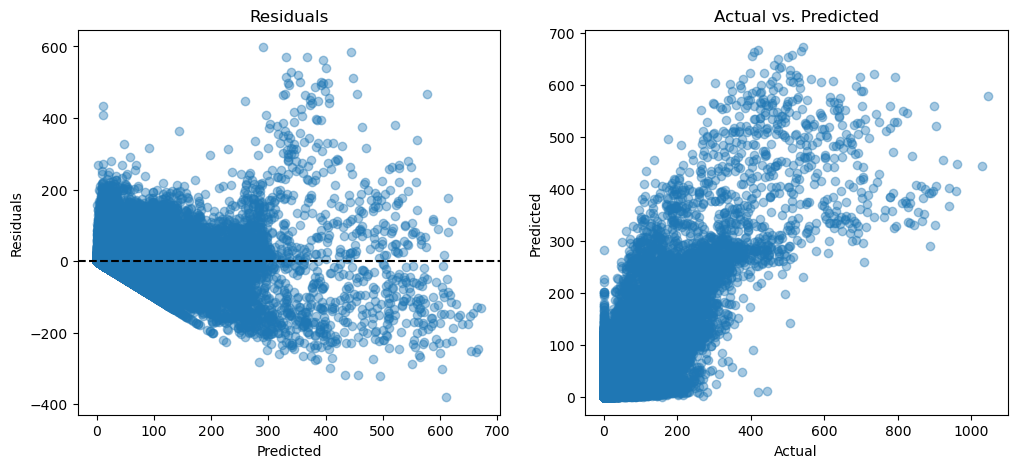

In [13]:
import helpers

training_predictions = np.expm1(scaler_y.inverse_transform(nn.predict(X_train_scaled).reshape(-1, 1)).flatten())
helpers.analysis(y_train, training_predictions)

# Test

18049/18049 ━━━━━━━━━━━━━━━━━━━━ 13s 704us/step
Mean Absolute Error: 	6.6776
Mean Squared Error: 	237.5861
R squared: 		0.6404


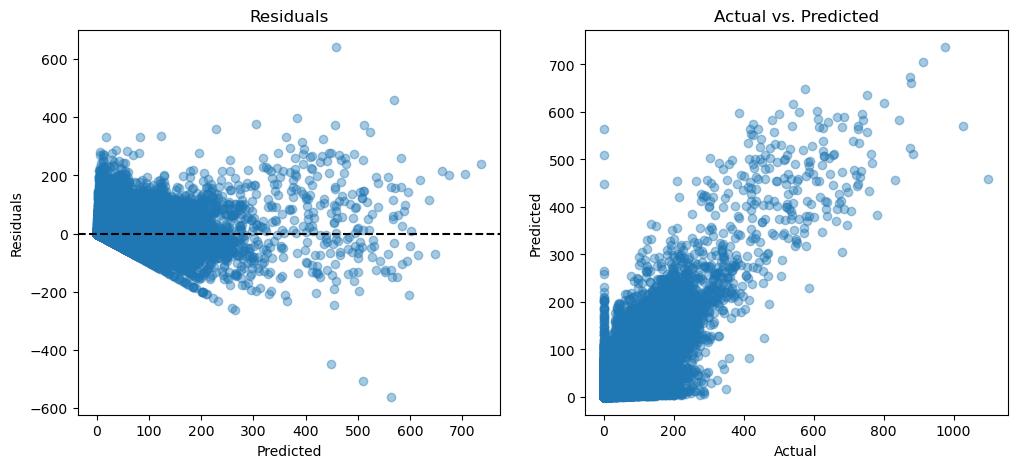

In [18]:
test_predictions = np.expm1(scaler_y.inverse_transform(nn.predict(X_test_scaled).reshape(-1, 1)).flatten())
helpers.analysis(y_test, test_predictions)